# Real Estate Market Analysis

***Introduction***

**Source Data**: The dataset is provided by the Yandex Real Estate service and contains an archive of apartment sales listings in Saint Petersburg and the surrounding areas collected over several years.

**Goal**: The objective is to identify the key parameters that influence the market value of real estate. The findings from this Exploratory Data Analysis (EDA) will be used to build an automated system capable of detecting anomalies and fraudulent activity in the listings.

The dataset includes two types of data for each property:

- User-generated data: Information entered manually by the seller.
- Automated (Spatial) data: Information calculated automatically based on map data (e.g., distance to the city center, airport, nearest parks, and bodies of water).

**Key Business Questions**:

- *Time to Sale*: How long does it typically take to sell an apartment? At what point is a sale considered "too fast" or "abnormally slow"?
- *Price Drivers*: Which factors have the strongest impact on the total market value of an apartment?
- *Location Analysis*: What is the average price per square meter in the top 10 locations with the highest number of listings?
- *City Center vs. Suburbs*: Which factors influence prices specifically in the Saint Petersburg city center, and how do they differ from the overall market trends?

## 1. Examining data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('real_estate_data.csv', sep='\t')

In [3]:
pd.set_option('display.max_columns', None)
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

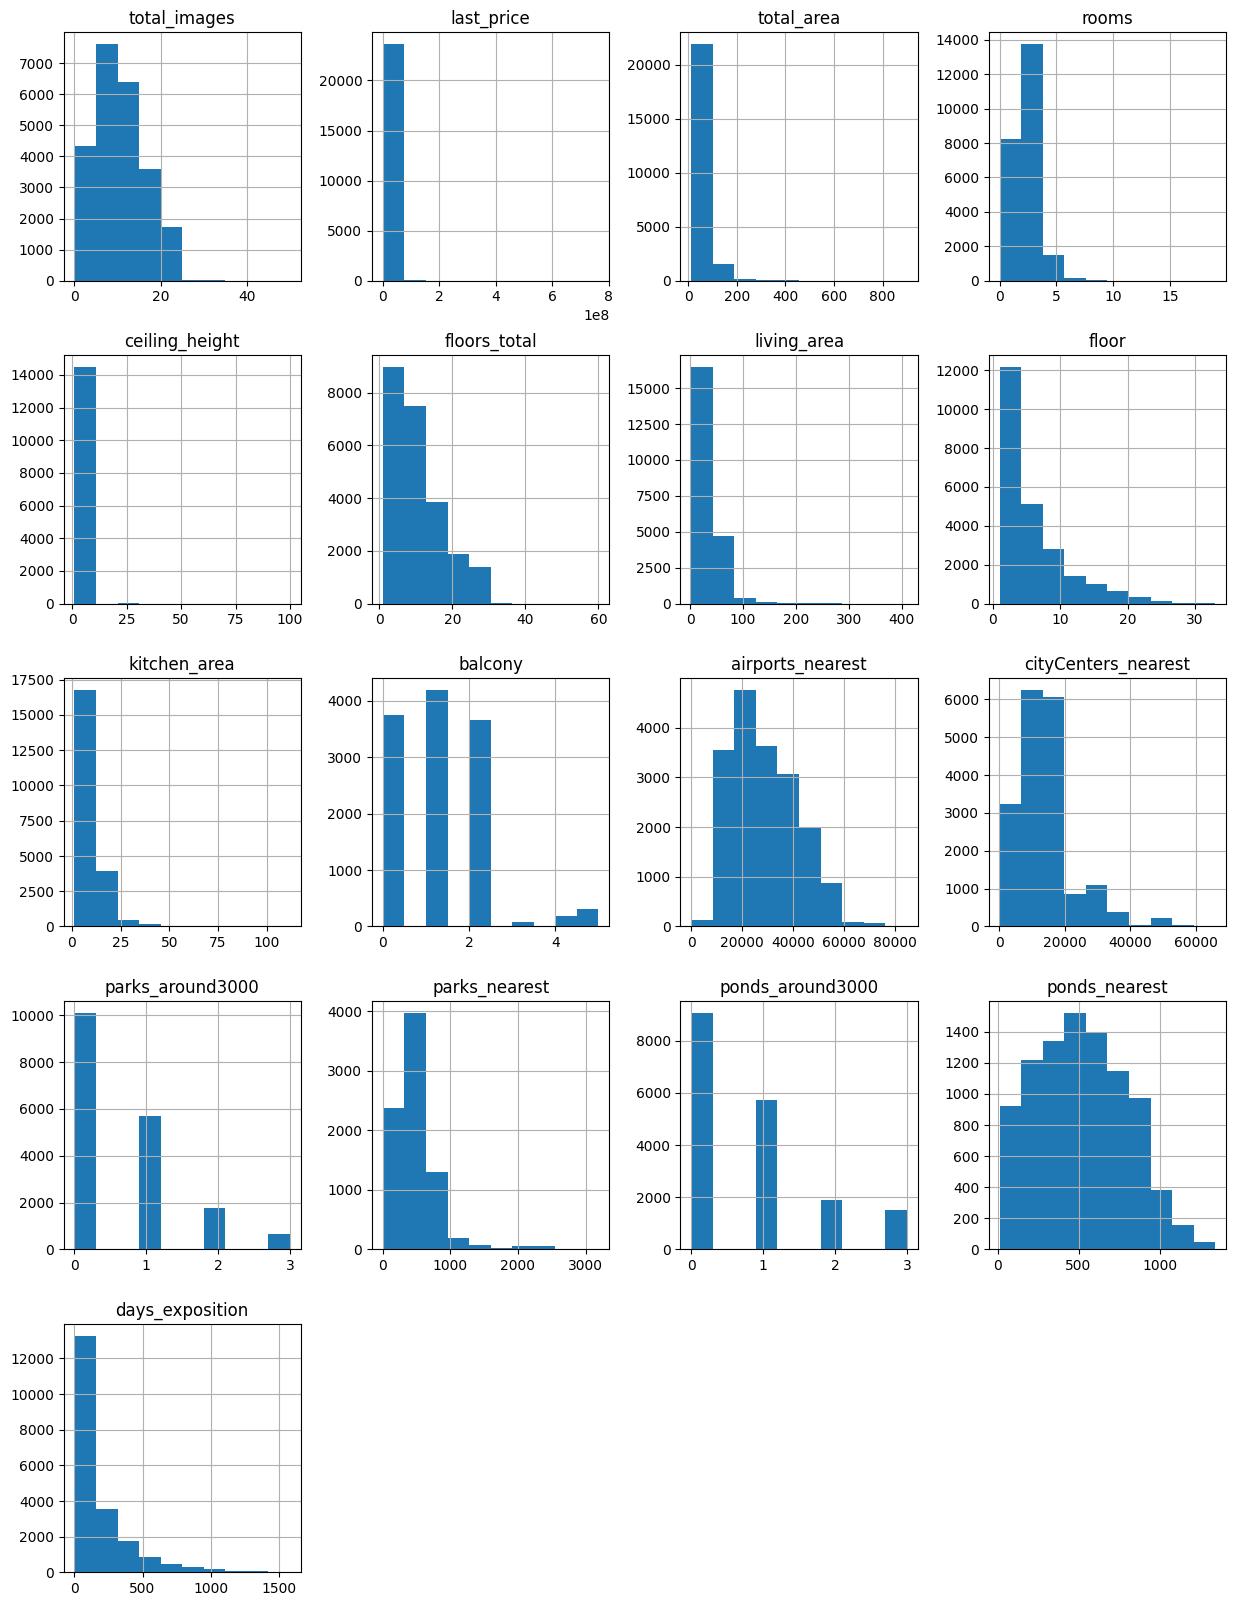

In [5]:
data.hist(figsize=(15,20)); #plotting histograms for all numeric columns

**Initial Data Inspection: Key Findings**

1. *Data Types:* The columns `floors_total`, `balcony`, `parks_around3000`, and `ponds_around3000` need to be converted to **integer** type. The `is_apartment` column should be **boolean**, and `first_day_exposition` needs to be converted to **datetime**.
2. *Style:* The `cityCenters_nearest` column name needs to be renamed to follow **snake_case** conventions.
3. *Missing Values:* There are missing values in several columns.
- *Human Factor:* Users may have left fields blank to imply a "zero" value (e.g., leaving the number of balconies blank because they don't have one).
- *Technical Issues:* Some missing data might be due to errors in the automated map generation process.
4. *Anomalies:* There are clear outliers and anomalous values, such as properties with 0 rooms in the `rooms` column or ceiling heights of 100 meters in the `ceiling_height` column.

**Data Description:**

- `total_images`(int64) - number of photos in the listing,
- `last_price`(float64) - price at the time the listing was removed,
- `total_area`(float64) - total apartment area in square meters (m²),
- `first_day_exposition`(object) - date of publication,
- `rooms`(int64) - number of rooms,
- `ceiling_height`(float64) - ceiling height (m),
- `floors_total`(float64) - total number of floors in the building,
- `living_area`(float64) - living area in square meters (m²),
- `floor`(int64) - the floor the apartment is located on,
- `is_apartment`(object) - apartment status,
- `studio`(bool) - whether the apartment is a studio,
- `open_plan`(bool) - whether the apartment has an open floor plan,
- `kitchen_area`(float64) - kitchen area in square meters (m²),
- `balcony`(float64) - number of balconies,
- `locality_name`(object) - name of the locality/settlement,
- `airports_nearest`(float64) - distance to the nearest airport (m),
- `cityCenters_nearest`(float64) - distance to the city center (m),
- `parks_around3000`(float64) - number of parks within a 3 km radius,
- `parks_nearest`(float64) - distance to the nearest park (m),
- `ponds_around3000`(float64) - number of bodies of water within a 3 km radius,
- `ponds_nearest`(float64) - distance to the nearest body of water (m),
- `days_exposition`(float64) - number of days the ad was listed (from publication to removal).

## 2. Data preprocessing

### 2.1 Gaps removal

In [6]:
data = data.rename(columns={'cityCenters_nearest':'city_centers_nearest'})

In [7]:
data.isna().sum() # count of missing values for each column

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [8]:
# balcony - filling 0s in gaps
data['balcony'] = data['balcony'].fillna(0)
data['balcony'].isna().value_counts()

balcony
False    23699
Name: count, dtype: int64

In [9]:
# parks_around3000 - filling 0s in gaps
data['parks_around3000'] = data['parks_around3000'].fillna(0)
data['parks_around3000'].isna().value_counts()

parks_around3000
False    23699
Name: count, dtype: int64

In [10]:
# ponds_around3000 - filling 0s in gaps
data['ponds_around3000'] = data['ponds_around3000'].fillna(0)
data['ponds_around3000'].isna().value_counts()

ponds_around3000
False    23699
Name: count, dtype: int64

In [11]:
#is_apartment - filling gaps with false values
data['is_apartment'] = data['is_apartment'].fillna(value=False)
data['is_apartment'].isna().value_counts()

/var/folders/br/y26yp_l16l55h_3qw9ndv4mr0000gn/T/ipykernel_68982/2299185834.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['is_apartment'] = data['is_apartment'].fillna(value=False)


is_apartment
False    23699
Name: count, dtype: int64

In [12]:
#ceiling_height - filling with median values
ceiling_height_avg = data['ceiling_height'].median()
data['ceiling_height'] = data['ceiling_height'].fillna(value=ceiling_height_avg)
data['ceiling_height'].isna().value_counts()

ceiling_height
False    23699
Name: count, dtype: int64

In [13]:
#kitchen_area & living_area

# ratio of kitchen area to total area
data['kitchen_ratio'] = data['kitchen_area'] / data['total_area']
# ratio of living area to total area
data['living_ratio'] = data['living_area'] / data['total_area']

In [14]:
# average area ratios typical for apartments
rates = data.pivot_table(index='rooms', values=['living_ratio', 'kitchen_ratio'], aggfunc='median').median()

#filling missing area values based on the ratios calculated in the previous step
#ensuring living + kitchen area does not exceed 90% of the total area (allowing 10% for utility spaces like hallways and bathrooms)
data.loc[(data['living_area'].isna()) | (data['kitchen_area'].isna()) |
    ((data['kitchen_area'] + data['living_area']) > data['total_area'] * 0.9), ['living_area', 'kitchen_area']] =\
    pd.DataFrame({'living_area': data['total_area'] * rates['living_ratio'], 'kitchen_area': data['total_area'] * 
                 rates['kitchen_ratio']})

In [15]:
data['living_area'].isna().value_counts()

living_area
False    23699
Name: count, dtype: int64

In [16]:
data['kitchen_area'].isna().value_counts()

kitchen_area
False    23699
Name: count, dtype: int64

In [17]:
# locality_name - dropping 49 rows with missing values
data = data.dropna(subset=['locality_name']).reset_index(drop=True)
data['locality_name'].isna().value_counts()

locality_name
False    23650
Name: count, dtype: int64

In [18]:
# floors_total - filling 86 missing values with the current floor number (ensuring a minimum of 5 floors)
data.loc[data['floors_total'].isna(), 'floors_total'] = data['floor'].where(data['floor'] > 4, 5)
data['floors_total'].isna().value_counts()

floors_total
False    23650
Name: count, dtype: int64

In [19]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5534
city_centers_nearest     5511
parks_around3000            0
parks_nearest           15586
ponds_around3000            0
ponds_nearest           14565
days_exposition          3180
kitchen_ratio            2269
living_ratio             1898
dtype: int64

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23650 entries, 0 to 23649
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23650 non-null  int64  
 1   last_price            23650 non-null  float64
 2   total_area            23650 non-null  float64
 3   first_day_exposition  23650 non-null  object 
 4   rooms                 23650 non-null  int64  
 5   ceiling_height        23650 non-null  float64
 6   floors_total          23650 non-null  float64
 7   living_area           23650 non-null  float64
 8   floor                 23650 non-null  int64  
 9   is_apartment          23650 non-null  bool   
 10  studio                23650 non-null  bool   
 11  open_plan             23650 non-null  bool   
 12  kitchen_area          23650 non-null  float64
 13  balcony               23650 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

***Missing Value Analysis & Handling Strategy***

The following missing values were identified and their potential causes were analyzed:

**1. Handled / Imputed Variables:**

- `balcony`: The seller likely left this blank because the apartment has no balcony. This is a human factor; I treated these missing values as 0.
- `parks_around3000` & `ponds_around3000`: These fields are populated automatically (not by the user), suggesting a technical error in the data generation process or that these fields are optional in the system.
- `is_apartment`: In this context, "apartments" refer to non-residential commercial properties (without permanent residency rights). If the seller skipped this field (human factor), it is safe to assume the property is standard residential housing. I filled these with False.
- `ceiling_height`: Likely missing due to the human factor; sellers may have considered this detail optional or low priority.
- `kitchen_area` & `living_area`: Likely due to the human factor. Sellers often provide only the `total_area` without breaking it down, or they estimate room sizes "by eye." This sometimes leads to anomalies where the sum of the kitchen and living areas exceeds the total area.
- `floors_total`: This is user-entered data (human factor) and was likely treated as optional by some sellers.
- `locality_name`: This is a critical field; without the location, the rest of the data loses its value. These rows might result from a database extraction error. Since I lack coordinates to restore the location, I decided to drop these rows.

**2. Variables Left Unchanged:**

- `parks_nearest`, `ponds_nearest`, `airports_nearest` & `city_centers_nearest`:

*Reason*: This is spatial data calculated automatically based on maps. The missing values are likely a technical issue (e.g., the system only calculates these for specific types of settlements).

*Decision*: I decided not to fill these gaps. Imputing distances without precise coordinates would distort the data.

- `days_exposition`:

*Reason*: This field shows how long an ad was active before being closed (sold). A missing value (NaN) likely indicates that the ad is still active (not yet sold).

*Decision*: Filling this with an arbitrary value would create anomalies, so I left it as is.

### 2.2 Data Types Conversion

The data types for the following columns will be changed:

- `floors_total`, `balcony`, `parks_around3000`, and `ponds_around3000` will be converted to *int*.
- `first_day_exposition` will be converted to *datetime*.

In [21]:
data['floors_total'] = data['floors_total'].astype('int')

In [22]:
data['balcony'] = data['balcony'].astype('int')

In [23]:
data['parks_around3000'] = data['parks_around3000'].astype('int')

In [24]:
data['ponds_around3000'] = data['ponds_around3000'].astype('int')

In [25]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

In [26]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,kitchen_ratio,living_ratio
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.000000,8,False,False,False,25.000000,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,0.231481,0.472222
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.600000,1,False,False,False,11.000000,2,посёлок Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,0.272277,0.460396
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.300000,4,False,False,False,8.300000,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,0.148214,0.612500
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,104.898701,9,False,False,False,16.288668,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0,NaN,NaN
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.000000,13,False,False,False,41.000000,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,0.410000,0.320000
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.400000,5,False,False,False,9.100000,0,городской посёлок Янино-1,NaN,NaN,0,NaN,0,NaN,55.0,0.299342,0.473684
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.600000,6,False,False,False,14.400000,1,посёлок Парголово,52996.0,19143.0,0,NaN,0,NaN,155.0,0.386059,0.284182
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,47.237403,22,False,False,False,7.335023,2,Санкт-Петербург,23982.0,11634.0,0,NaN,0,NaN,NaN,0.263966,NaN
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.430000,26,False,False,False,8.810000,0,посёлок Мурино,NaN,NaN,0,NaN,0,NaN,189.0,0.265682,0.465320
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.600000,7,False,False,False,6.500000,2,Санкт-Петербург,50898.0,15008.0,0,NaN,0,NaN,289.0,0.106557,0.714754


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23650 entries, 0 to 23649
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  float64       
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        23650 non-null  float64       
 6   floors_total          23650 non-null  int64         
 7   living_area           23650 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          23650 non-null  bool          
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          23650 non-null  float64       
 13  balcony         

In this section, the data types were updated for specific columns based on the following logic:

- `is_apartment`: After filling missing values (NaN) with False in the previous step, the column automatically converted from object to bool.
- `parks_around3000` & `ponds_around3000`: Since it is logically impossible to have "2.5 parks" or "1.5 ponds," I converted these variables to integers.
- `floors_total` & `balcony`: Similarly, a building cannot have "10.3 floors" or "1.5 balconies." Therefore, I converted these columns to int64.
- `first_day_exposition`: Standard change of the date strings into the datetime format.

### 2.3 Duplicates handling

In [28]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [29]:
len(data['locality_name'].unique())

364

Upon inspecting the unique values, implicit duplicates were identified that need to be eliminated. These are primarily caused by spelling inconsistencies (e.g., using 'е' vs. 'ё') and varying naming conventions.

*Examples:*

- 'поселок' vs. 'посёлок'
- 'городской посёлок Янино-1' vs. 'городской поселок Янино-1'
- 'посёлок Мурино' vs. 'поселок Мурино' vs. 'Мурино'

In [30]:
# applying vectorized string splitting to eliminate implicit duplicates in the locality_name column
data.loc[:, ['locality_type', 'locality_clean_name']] =\
    data['locality_name'].str.split(pat='(?=[A-Я])', n=1, expand=True).to_numpy()

In [31]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,kitchen_ratio,living_ratio,locality_type,locality_clean_name
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.000000,8,False,False,False,25.000000,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,0.231481,0.472222,,Санкт-Петербург
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.600000,1,False,False,False,11.000000,2,посёлок Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,0.272277,0.460396,посёлок,Шушары
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.300000,4,False,False,False,8.300000,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,0.148214,0.612500,,Санкт-Петербург
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,104.898701,9,False,False,False,16.288668,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0,NaN,NaN,,Санкт-Петербург
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.000000,13,False,False,False,41.000000,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,0.410000,0.320000,,Санкт-Петербург
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.400000,5,False,False,False,9.100000,0,городской посёлок Янино-1,NaN,NaN,0,NaN,0,NaN,55.0,0.299342,0.473684,городской посёлок,Янино-1
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.600000,6,False,False,False,14.400000,1,посёлок Парголово,52996.0,19143.0,0,NaN,0,NaN,155.0,0.386059,0.284182,посёлок,Парголово
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,47.237403,22,False,False,False,7.335023,2,Санкт-Петербург,23982.0,11634.0,0,NaN,0,NaN,NaN,0.263966,NaN,,Санкт-Петербург
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.430000,26,False,False,False,8.810000,0,посёлок Мурино,NaN,NaN,0,NaN,0,NaN,189.0,0.265682,0.465320,посёлок,Мурино
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.600000,7,False,False,False,6.500000,2,Санкт-Петербург,50898.0,15008.0,0,NaN,0,NaN,289.0,0.106557,0.714754,,Санкт-Петербург


In [32]:
data['locality_type'].unique()

array(['', 'посёлок ', 'городской посёлок ', 'деревня ',
       'поселок городского типа ', 'поселок ', 'посёлок городского типа ',
       'садовое товарищество ', 'село ', 'городской поселок ',
       'поселок городского типа имени ', 'поселок станции ',
       'посёлок городского типа имени ',
       'садоводческое некоммерческое товарищество ',
       'посёлок при железнодорожной станции ', 'посёлок станции ',
       'коттеджный поселок ', 'коттеджный посёлок '], dtype=object)

In [33]:
# eliminated implicit duplicates in locality types
data['locality_type'] = (
    data['locality_type']
    .str.replace('ё', 'е')
    .replace(['городской поселок', 'поселок городского типа имени', 'поселок городского типа', 'поселок станции',
             'поселок при железнодорожной станции', 'коттеджный поселок'], 'поселок'))

In [34]:
data['locality_type'].unique()

array(['', 'поселок ', 'городской поселок ', 'деревня ',
       'поселок городского типа ', 'садовое товарищество ', 'село ',
       'поселок городского типа имени ', 'поселок станции ',
       'садоводческое некоммерческое товарищество ',
       'поселок при железнодорожной станции ', 'коттеджный поселок '],
      dtype=object)

In [35]:
data['locality_clean_name'].unique()

array(['Санкт-Петербург', 'Шушары', 'Янино-1', 'Парголово', 'Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', 'Кудрово',
       'Коммунар', 'Колпино', 'Красный Бор', 'Гатчина', 'Фёдоровское',
       'Выборг', 'Кронштадт', 'Кировск', 'Новое Девяткино',
       'Металлострой', 'Лебяжье', 'Сиверский', 'Молодцово',
       'Кузьмоловский', 'Новая Ропша', 'Павловск', 'Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'Куттузи', 'Аннино', 'Ефимовский', 'Плодовое', 'Заклинье',
       'Торковичи', 'Первомайское', 'Красное Село', 'Понтонный',
       'Сясьстрой', 'Старая', 'Лесколово', 'Новый Свет', 'Сланцы',
       'Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', 'Оржицы', 'Кальтино', 'Романовка',
       'Бугры', 'Рощино', 'Кириши', 'Луга', 'Волосово', 'Отрадное',
       'Павлово', 'Оредеж', 'Копорье', 'Молодёжное', 'Тихвин', 'Победа',
       'Нурма', 'Синявино', 'Тосно', 'Стрельна', 'Бокситогорск',

In [36]:
len(data['locality_clean_name'].unique())

305

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23650 entries, 0 to 23649
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  float64       
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        23650 non-null  float64       
 6   floors_total          23650 non-null  int64         
 7   living_area           23650 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          23650 non-null  bool          
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          23650 non-null  float64       
 13  balcony         

**Conclusion:** Separating the locality types from the locality names allowed to extract a column of "clean" names, effectively eliminating the majority of implicit duplicates. The locality types were also standardized to remove inconsistencies.

### 2.4 Handling abnormal values

- **`ceiling_height` variable**

In [38]:
len(data['ceiling_height'].unique())

183

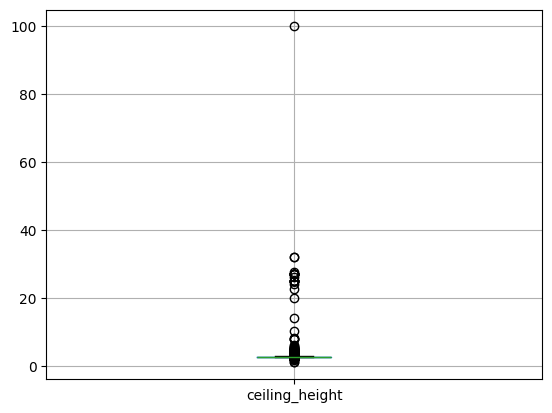

In [39]:
data.boxplot(column='ceiling_height');

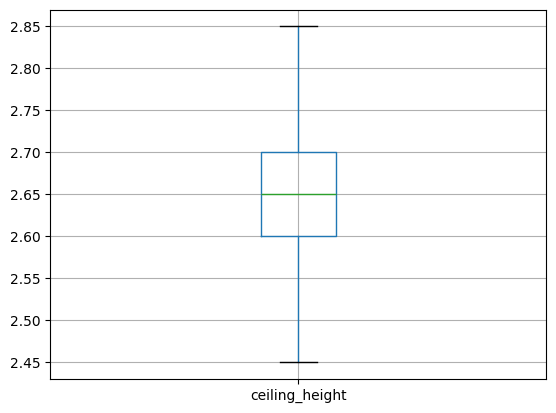

In [40]:
data.boxplot(column='ceiling_height', showfliers=False);

In [41]:
data['ceiling_height'].sort_values(ascending=False).unique()

array([100.  ,  32.  ,  27.5 ,  27.  ,  26.  ,  25.  ,  24.  ,  22.6 ,
        20.  ,  14.  ,  10.3 ,   8.3 ,   8.  ,   6.  ,   5.8 ,   5.6 ,
         5.5 ,   5.3 ,   5.2 ,   5.  ,   4.9 ,   4.8 ,   4.7 ,   4.65,
         4.5 ,   4.45,   4.4 ,   4.37,   4.3 ,   4.25,   4.2 ,   4.19,
         4.15,   4.14,   4.1 ,   4.06,   4.  ,   3.98,   3.95,   3.93,
         3.9 ,   3.88,   3.87,   3.86,   3.85,   3.84,   3.83,   3.82,
         3.8 ,   3.78,   3.76,   3.75,   3.7 ,   3.69,   3.68,   3.67,
         3.66,   3.65,   3.63,   3.62,   3.6 ,   3.59,   3.58,   3.57,
         3.56,   3.55,   3.54,   3.53,   3.52,   3.51,   3.5 ,   3.49,
         3.48,   3.47,   3.46,   3.45,   3.44,   3.43,   3.42,   3.4 ,
         3.39,   3.38,   3.37,   3.36,   3.35,   3.34,   3.33,   3.32,
         3.31,   3.3 ,   3.29,   3.28,   3.27,   3.26,   3.25,   3.24,
         3.23,   3.22,   3.21,   3.2 ,   3.18,   3.17,   3.16,   3.15,
         3.14,   3.13,   3.12,   3.11,   3.1 ,   3.09,   3.08,   3.07,
      

In [42]:
data['ceiling_height'].describe()

count    23650.000000
mean         2.724311
std          0.989255
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

In [43]:
# handling ceiling height outliers (values > 10)
data.loc[data['ceiling_height'] > 10, 'ceiling_height'] /= 10

In [44]:
data['ceiling_height'].sort_values(ascending=False).unique()

array([10.  ,  8.3 ,  8.  ,  6.  ,  5.8 ,  5.6 ,  5.5 ,  5.3 ,  5.2 ,
        5.  ,  4.9 ,  4.8 ,  4.7 ,  4.65,  4.5 ,  4.45,  4.4 ,  4.37,
        4.3 ,  4.25,  4.2 ,  4.19,  4.15,  4.14,  4.1 ,  4.06,  4.  ,
        3.98,  3.95,  3.93,  3.9 ,  3.88,  3.87,  3.86,  3.85,  3.84,
        3.83,  3.82,  3.8 ,  3.78,  3.76,  3.75,  3.7 ,  3.69,  3.68,
        3.67,  3.66,  3.65,  3.63,  3.62,  3.6 ,  3.59,  3.58,  3.57,
        3.56,  3.55,  3.54,  3.53,  3.52,  3.51,  3.5 ,  3.49,  3.48,
        3.47,  3.46,  3.45,  3.44,  3.43,  3.42,  3.4 ,  3.39,  3.38,
        3.37,  3.36,  3.35,  3.34,  3.33,  3.32,  3.31,  3.3 ,  3.29,
        3.28,  3.27,  3.26,  3.25,  3.24,  3.23,  3.22,  3.21,  3.2 ,
        3.18,  3.17,  3.16,  3.15,  3.14,  3.13,  3.12,  3.11,  3.1 ,
        3.09,  3.08,  3.07,  3.06,  3.05,  3.04,  3.03,  3.02,  3.01,
        3.  ,  2.99,  2.98,  2.97,  2.96,  2.95,  2.94,  2.93,  2.92,
        2.91,  2.9 ,  2.89,  2.88,  2.87,  2.86,  2.85,  2.84,  2.83,
        2.82,  2.81,

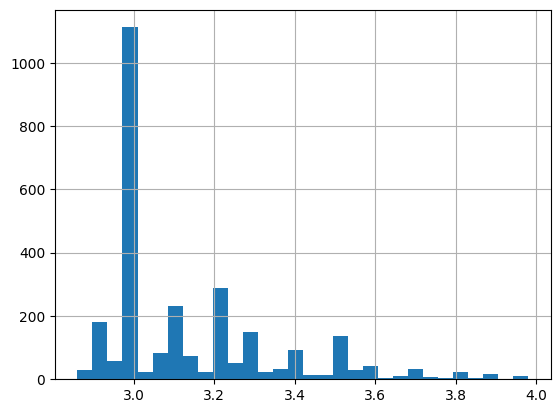

In [45]:
data[(data['ceiling_height'] > 2.85) & (data['ceiling_height'] < 4)]['ceiling_height'].hist(bins=30);

In [46]:
# removing values outside the range
data = data.query('2.45 <= ceiling_height <= 3.6').reset_index(drop=True)

In [47]:
data['ceiling_height'].sort_values(ascending=False).unique()

array([3.6 , 3.59, 3.58, 3.57, 3.56, 3.55, 3.54, 3.53, 3.52, 3.51, 3.5 ,
       3.49, 3.48, 3.47, 3.46, 3.45, 3.44, 3.43, 3.42, 3.4 , 3.39, 3.38,
       3.37, 3.36, 3.35, 3.34, 3.33, 3.32, 3.31, 3.3 , 3.29, 3.28, 3.27,
       3.26, 3.25, 3.24, 3.23, 3.22, 3.21, 3.2 , 3.18, 3.17, 3.16, 3.15,
       3.14, 3.13, 3.12, 3.11, 3.1 , 3.09, 3.08, 3.07, 3.06, 3.05, 3.04,
       3.03, 3.02, 3.01, 3.  , 2.99, 2.98, 2.97, 2.96, 2.95, 2.94, 2.93,
       2.92, 2.91, 2.9 , 2.89, 2.88, 2.87, 2.86, 2.85, 2.84, 2.83, 2.82,
       2.81, 2.8 , 2.79, 2.78, 2.77, 2.76, 2.75, 2.74, 2.73, 2.72, 2.71,
       2.7 , 2.69, 2.68, 2.67, 2.66, 2.65, 2.64, 2.63, 2.62, 2.61, 2.6 ,
       2.59, 2.58, 2.57, 2.56, 2.55, 2.54, 2.53, 2.52, 2.51, 2.5 , 2.49,
       2.48, 2.47, 2.46, 2.45])

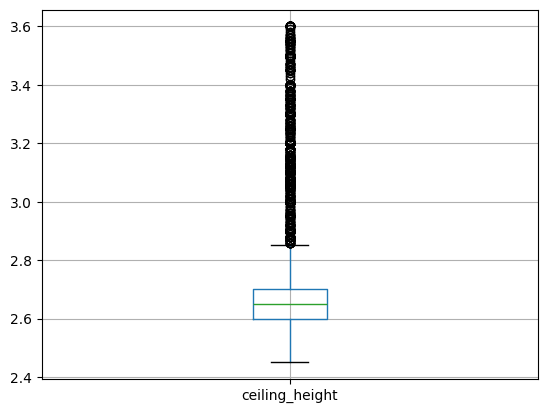

In [48]:
data.boxplot(column='ceiling_height');

In [49]:
len(data['ceiling_height'].unique())

114

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23400 entries, 0 to 23399
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23400 non-null  int64         
 1   last_price            23400 non-null  float64       
 2   total_area            23400 non-null  float64       
 3   first_day_exposition  23400 non-null  datetime64[ns]
 4   rooms                 23400 non-null  int64         
 5   ceiling_height        23400 non-null  float64       
 6   floors_total          23400 non-null  int64         
 7   living_area           23400 non-null  float64       
 8   floor                 23400 non-null  int64         
 9   is_apartment          23400 non-null  bool          
 10  studio                23400 non-null  bool          
 11  open_plan             23400 non-null  bool          
 12  kitchen_area          23400 non-null  float64       
 13  balcony         

**Conclusion:** The `ceiling_height` variable was analyzed, and a boxplot was used to identify and remove outliers (unrealistic or anomalous values) from the dataframe.
- *Average height*: 2.65 meters.
- *Range*: The data was filtered to include only values between 2.45 meters (min) and 3.6 meters (max).

- **`last_price` variable**

In [51]:
len(data['last_price'].unique())

2933

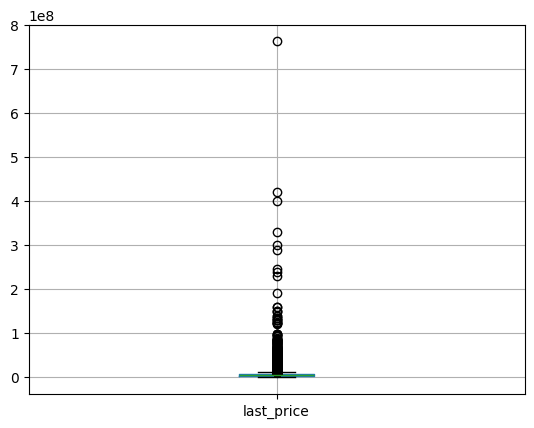

In [52]:
data.boxplot(column='last_price');

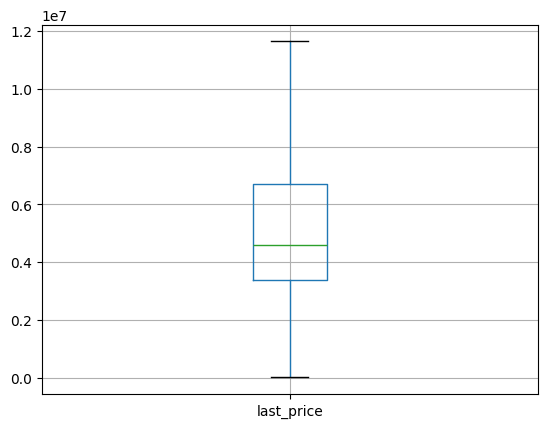

In [53]:
data.boxplot(column='last_price', showfliers=False);

In [54]:
data['last_price'].sort_values()

8673         12190.0
14723       430000.0
17232       430000.0
16066       440000.0
5618        450000.0
            ...     
15450    300000000.0
1414     330000000.0
14520    401300000.0
19294    420000000.0
12807    763000000.0
Name: last_price, Length: 23400, dtype: float64

In [55]:
data['last_price'].describe()

count    2.340000e+04
mean     6.402084e+06
std      1.043936e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.600000e+06
75%      6.700000e+06
max      7.630000e+08
Name: last_price, dtype: float64

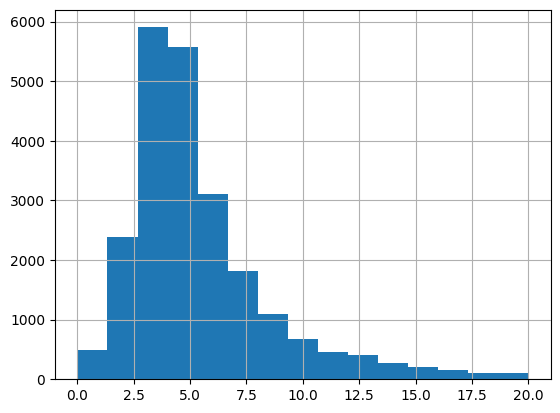

In [56]:
(data['last_price']/1000000).hist(range=(0, 20), bins=15);

In [57]:
data = data.query('12190.00 < last_price < 20000000.00').reset_index(drop=True)

In [58]:
data['last_price'].sort_values()

16738      430000.0
14316      430000.0
15611      440000.0
5459       450000.0
9191       450000.0
            ...    
20175    19950000.0
6082     19980000.0
3721     19990000.0
21262    19990000.0
927      19999000.0
Name: last_price, Length: 22726, dtype: float64

In [59]:
data['last_price'].describe()

count    2.272600e+04
mean     5.382876e+06
std      3.160615e+06
min      4.300000e+05
25%      3.400000e+06
50%      4.550000e+06
75%      6.450000e+06
max      1.999900e+07
Name: last_price, dtype: float64

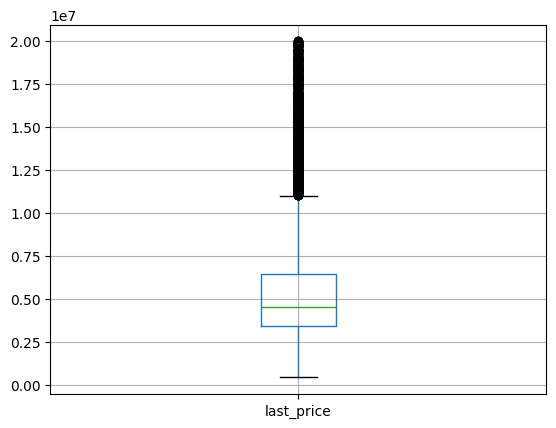

In [60]:
data.boxplot(column='last_price');

In [61]:
len(data['last_price'].unique())

2579

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22726 entries, 0 to 22725
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          22726 non-null  int64         
 1   last_price            22726 non-null  float64       
 2   total_area            22726 non-null  float64       
 3   first_day_exposition  22726 non-null  datetime64[ns]
 4   rooms                 22726 non-null  int64         
 5   ceiling_height        22726 non-null  float64       
 6   floors_total          22726 non-null  int64         
 7   living_area           22726 non-null  float64       
 8   floor                 22726 non-null  int64         
 9   is_apartment          22726 non-null  bool          
 10  studio                22726 non-null  bool          
 11  open_plan             22726 non-null  bool          
 12  kitchen_area          22726 non-null  float64       
 13  balcony         

**Conclusion:** The `last_price` variable was analyzed, and outliers (anomalously low and high property prices) were identified using a boxplot and removed from the main dataframe. Based on the boxplot and additional analysis, the average apartment price in the processed dataset is 4.6 million. The data was filtered to include a range between a minimum of 430,000 and a maximum of 20 million.

- **`city_centers_nearest` variable**

In [63]:
len(data['city_centers_nearest'].unique())

7353

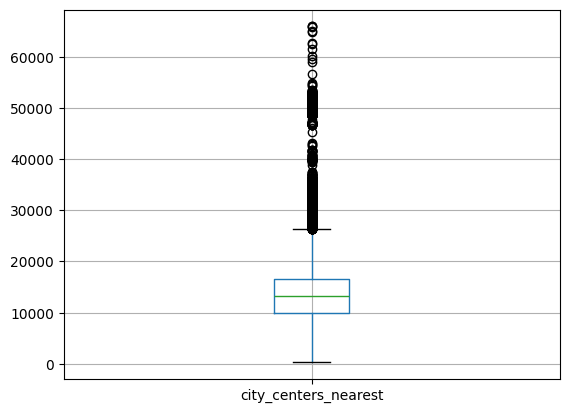

In [64]:
data.boxplot(column='city_centers_nearest');

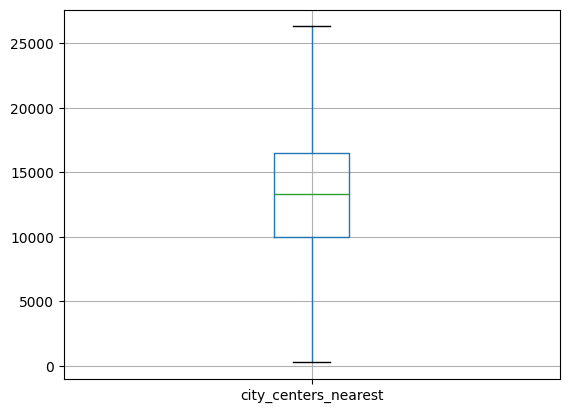

In [65]:
data.boxplot(column='city_centers_nearest', showfliers=False);

In [66]:
data['city_centers_nearest'].describe()

count    17265.000000
mean     14572.451723
std       8541.256562
min        287.000000
25%       9963.000000
50%      13321.000000
75%      16495.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

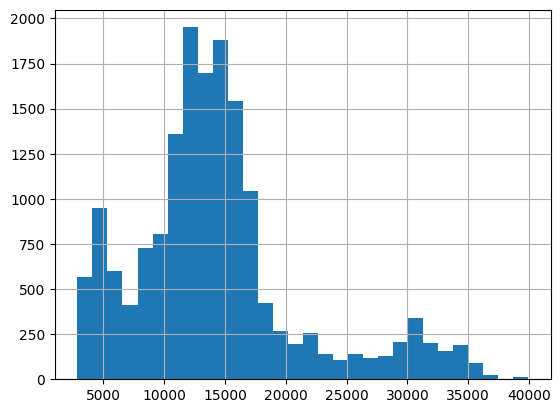

In [67]:
data[(data['city_centers_nearest'] > 2878.0) & 
    (data['city_centers_nearest'] < 40000.0)]['city_centers_nearest'].hist(bins=30);

In [68]:
data = data.query('287.0 <= city_centers_nearest <= 36000.0 or city_centers_nearest.isna()').reset_index(drop=True)

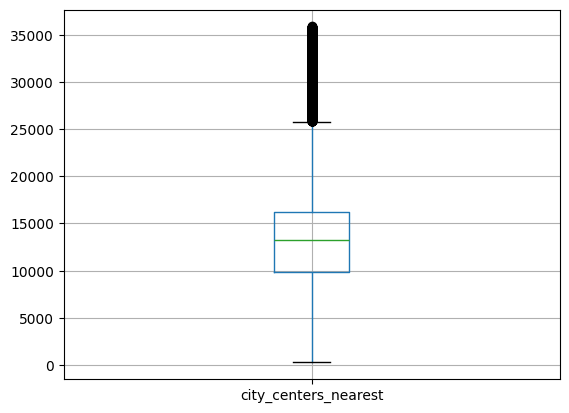

In [69]:
data.boxplot(column='city_centers_nearest');

In [70]:
len(data['city_centers_nearest'].unique())

7116

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22392 entries, 0 to 22391
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          22392 non-null  int64         
 1   last_price            22392 non-null  float64       
 2   total_area            22392 non-null  float64       
 3   first_day_exposition  22392 non-null  datetime64[ns]
 4   rooms                 22392 non-null  int64         
 5   ceiling_height        22392 non-null  float64       
 6   floors_total          22392 non-null  int64         
 7   living_area           22392 non-null  float64       
 8   floor                 22392 non-null  int64         
 9   is_apartment          22392 non-null  bool          
 10  studio                22392 non-null  bool          
 11  open_plan             22392 non-null  bool          
 12  kitchen_area          22392 non-null  float64       
 13  balcony         

**Conclusion:** The `city_centers_nearest` variable was analyzed, and outliers (apartments anomalously distant from the center of Saint Petersburg) were identified using a boxplot and removed from the dataframe. Based on the boxplot and additional analysis, the average distance from the city center in the processed data is 13.321 km, with a minimum of 287 m and a maximum of 36 km.

- **`total_area` variable**

In [72]:
len(data['total_area'].unique())

1919

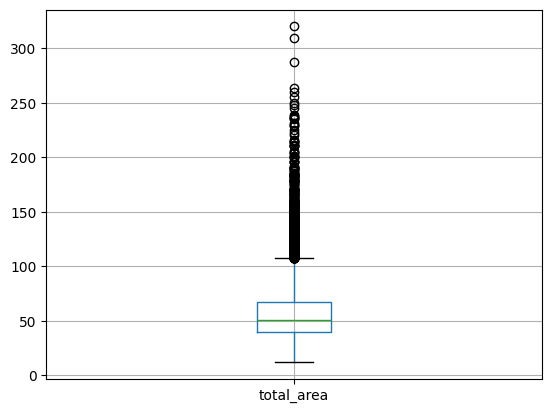

In [73]:
data.boxplot(column='total_area');

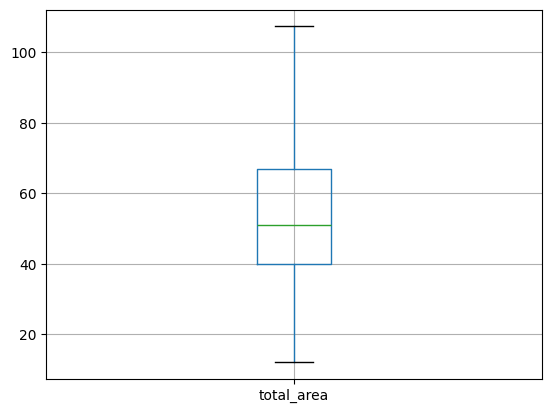

In [74]:
data.boxplot(column='total_area', showfliers=False);

In [75]:
data['total_area'].sort_values()

18810     12.0
18469     13.0
16974     13.0
18717     13.0
18481     13.2
         ...  
11427    259.6
8898     263.8
21008    287.5
12683    309.7
10504    320.0
Name: total_area, Length: 22392, dtype: float64

In [76]:
data['total_area'].describe()

count    22392.000000
mean        56.526311
std         24.383692
min         12.000000
25%         40.000000
50%         51.000000
75%         67.000000
max        320.000000
Name: total_area, dtype: float64

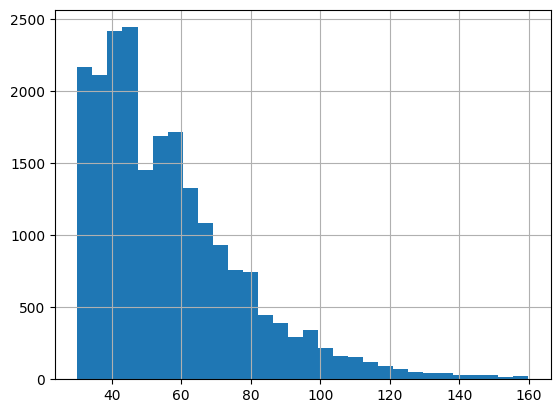

In [77]:
data[(data['total_area'] > 30.0) & (data['total_area'] < 160)]['total_area'].hist(bins=30);

In [78]:
data = data.query('30.0 <= total_area <= 120.0').reset_index(drop=True)

In [79]:
data['total_area'].sort_values()

10616     30.0
11388     30.0
11553     30.0
11576     30.0
11687     30.0
         ...  
9968     120.0
18637    120.0
11830    120.0
19329    120.0
16485    120.0
Name: total_area, Length: 21234, dtype: float64

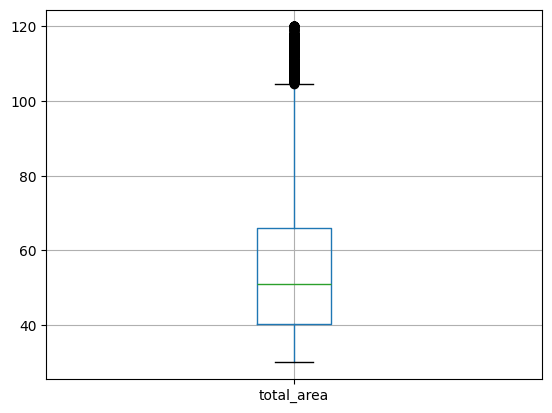

In [80]:
data.boxplot(column='total_area');

In [81]:
len(data['total_area'].unique())

1513

In [82]:
data['total_area'].describe()

count    21234.000000
mean        55.370776
std         19.324777
min         30.000000
25%         40.400000
50%         51.000000
75%         66.100000
max        120.000000
Name: total_area, dtype: float64

In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21234 entries, 0 to 21233
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          21234 non-null  int64         
 1   last_price            21234 non-null  float64       
 2   total_area            21234 non-null  float64       
 3   first_day_exposition  21234 non-null  datetime64[ns]
 4   rooms                 21234 non-null  int64         
 5   ceiling_height        21234 non-null  float64       
 6   floors_total          21234 non-null  int64         
 7   living_area           21234 non-null  float64       
 8   floor                 21234 non-null  int64         
 9   is_apartment          21234 non-null  bool          
 10  studio                21234 non-null  bool          
 11  open_plan             21234 non-null  bool          
 12  kitchen_area          21234 non-null  float64       
 13  balcony         

**Conclusion:** The `total_area` variable was analyzed, and outliers (apartments with anomalously small or large areas) were identified using a boxplot and removed from the dataframe. Based on the boxplot and additional analysis, the average apartment area in the processed data is 51 m², with a minimum of 30 m² and a maximum of 120 m².

## 3. Feature Engineering

In [84]:
# Price per square meter (rounded to 2 decimal places)
data['price_per_sqm'] = round(data['last_price'] / data['total_area'], 2)

In [85]:
# Day of the week of publication (0 = Monday, 1 = Tuesday, etc.)
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday

In [86]:
# Publication month
data['month_exposition'] = data['first_day_exposition'].dt.month

In [87]:
# Publication year
data['year_exposition'] = data['first_day_exposition'].dt.year

In [88]:
# Floor category (values: 'first', 'last', 'other')
def floor_group(row):
    if row['floor'] == 1:
        return 'first'
    if row['floor'] == row['floors_total']:
        return 'last'
    else:
        return 'other'
data['floor_group'] = data.apply(floor_group, axis=1)

In [89]:
data['floor_group'].value_counts()

floor_group
other    15634
last      2968
first     2632
Name: count, dtype: int64

In [90]:
# Distance to the city center in km (converted from meters and rounded to the nearest integer)
data['city_centers_nearest_km'] = round(data['city_centers_nearest']/1000)

In [91]:
data.head(30)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,kitchen_ratio,living_ratio,locality_type,locality_clean_name,price_per_sqm,weekday_exposition,month_exposition,year_exposition,floor_group,city_centers_nearest_km
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.000000,8,False,False,False,25.000000,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,0.231481,0.472222,,Санкт-Петербург,120370.37,3,3,2019,other,16.0
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.600000,1,False,False,False,11.000000,2,посёлок Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,0.272277,0.460396,поселок,Шушары,82920.79,1,12,2018,first,19.0
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.300000,4,False,False,False,8.300000,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,0.148214,0.612500,,Санкт-Петербург,92785.71,3,8,2015,other,14.0
3,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.000000,13,False,False,False,41.000000,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,0.410000,0.320000,,Санкт-Петербург,100000.00,1,6,2018,other,8.0
4,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.400000,5,False,False,False,9.100000,0,городской посёлок Янино-1,NaN,NaN,0,NaN,0,NaN,55.0,0.299342,0.473684,городской поселок,Янино-1,95065.79,0,9,2018,other,NaN
5,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.600000,6,False,False,False,14.400000,1,посёлок Парголово,52996.0,19143.0,0,NaN,0,NaN,155.0,0.386059,0.284182,поселок,Парголово,99195.71,3,11,2017,other,19.0
6,5,7915000.0,71.60,2019-04-18,2,2.65,24,47.237403,22,False,False,False,7.335023,2,Санкт-Петербург,23982.0,11634.0,0,NaN,0,NaN,NaN,0.263966,NaN,,Санкт-Петербург,110544.69,3,4,2019,other,12.0
7,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.430000,26,False,False,False,8.810000,0,посёлок Мурино,NaN,NaN,0,NaN,0,NaN,189.0,0.265682,0.465320,поселок,Мурино,87454.76,2,5,2018,other,NaN
8,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.600000,7,False,False,False,6.500000,2,Санкт-Петербург,50898.0,15008.0,0,NaN,0,NaN,289.0,0.106557,0.714754,,Санкт-Петербург,88524.59,6,2,2017,other,15.0
9,5,5050000.0,39.60,2017-11-16,1,2.67,12,20.300000,3,False,False,False,8.500000,0,Санкт-Петербург,38357.0,13878.0,1,310.0,2,553.0,137.0,0.214646,0.512626,,Санкт-Петербург,127525.25,3,11,2017,other,14.0


**Conclusion:** Data preparation for hypothesis testing was completed in this section. The number of columns has increased by 10 since the start of the analysis (now totaling 32); these additional features will be utilized in the subsequent exploratory data analysis.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Analysis and Description of Key Variables using Histograms

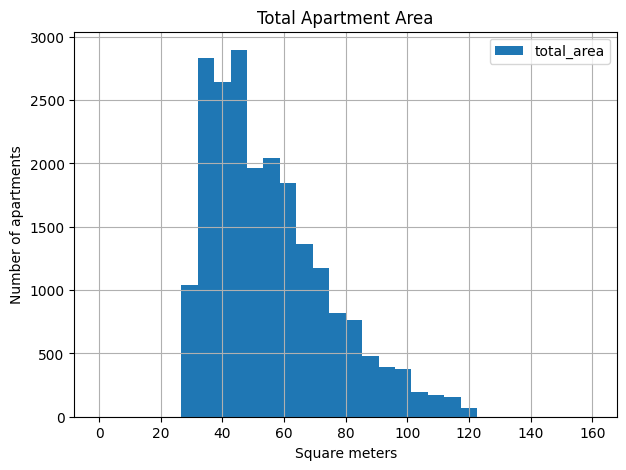

In [92]:
# total_area
data.plot(y = 'total_area', kind = 'hist', bins = 30, grid=True, figsize = (7,5), range = (0,160))
plt.title('Total Apartment Area')
plt.xlabel('Square meters')
plt.ylabel('Number of apartments')
plt.show()

In [93]:
data['total_area'].describe()

count    21234.000000
mean        55.370776
std         19.324777
min         30.000000
25%         40.400000
50%         51.000000
75%         66.100000
max        120.000000
Name: total_area, dtype: float64

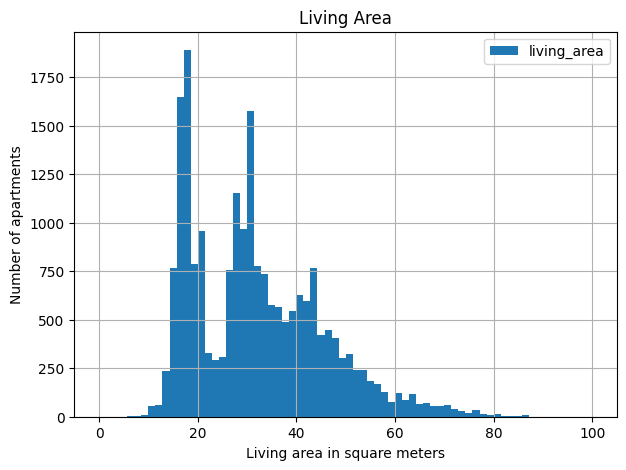

In [94]:
# living_area
data.plot(y = 'living_area', kind = 'hist', bins = 70, grid=True, figsize = (7,5), range = (0,100))
plt.title('Living Area')
plt.xlabel('Living area in square meters')
plt.ylabel('Number of apartments')
plt.show()

In [95]:
data['living_area'].describe()

count    21234.000000
mean        31.984422
std         13.490974
min          2.000000
25%         19.400000
50%         30.000000
75%         41.000000
max         95.000000
Name: living_area, dtype: float64

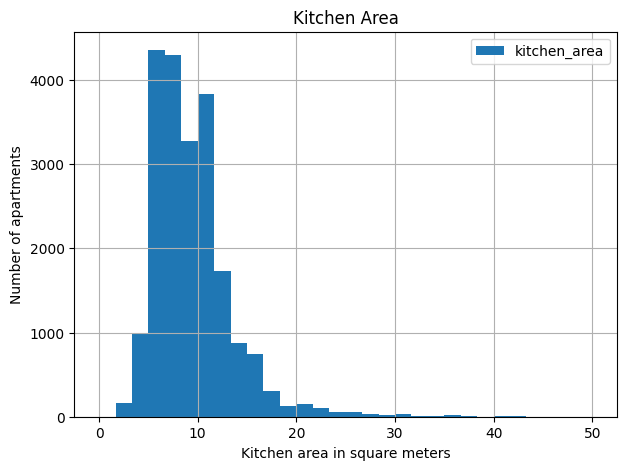

In [96]:
# kitchen_area
data.plot(y = 'kitchen_area', kind = 'hist', bins = 30, grid=True, figsize = (7,5), range = (0,50))
plt.title('Kitchen Area')
plt.xlabel('Kitchen area in square meters')
plt.ylabel('Number of apartments')
plt.show()

In [97]:
data['kitchen_area'].describe()

count    21234.000000
mean         9.386591
std          4.179925
min          2.000000
25%          6.500000
50%          8.700000
75%         11.000000
max         64.000000
Name: kitchen_area, dtype: float64

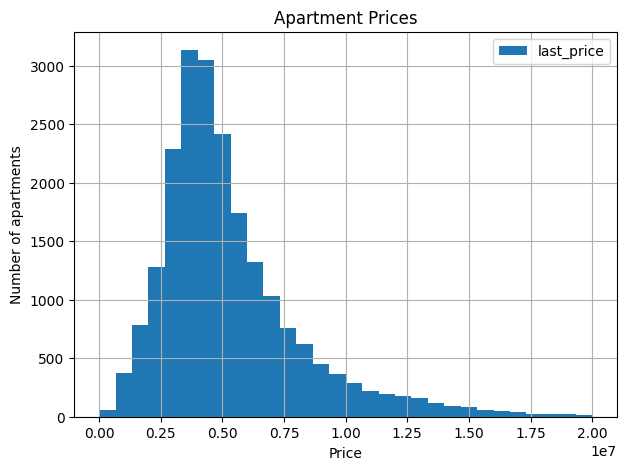

In [98]:
# last_price
data.plot(y = 'last_price', kind = 'hist', bins = 30, grid=True, figsize = (7,5), range = (0,20000000))
plt.title('Apartment Prices')
plt.xlabel('Price')
plt.ylabel('Number of apartments')
plt.show()

In [99]:
data['last_price'].describe()

count    2.123400e+04
mean     5.289273e+06
std      2.882226e+06
min      4.300000e+05
25%      3.450000e+06
50%      4.600000e+06
75%      6.400000e+06
max      1.999900e+07
Name: last_price, dtype: float64

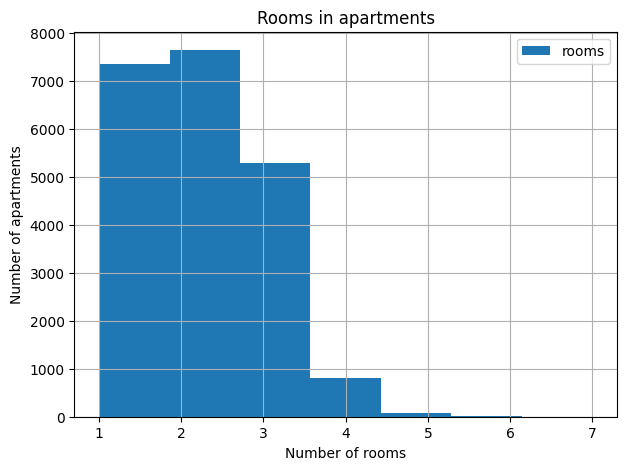

In [100]:
# rooms
data.plot(y = 'rooms', kind = 'hist', bins = 7, grid=True, figsize = (7,5), range = (1,7))
plt.title('Rooms in apartments')
plt.xlabel('Number of rooms')
plt.ylabel('Number of apartments')
plt.show()

In [101]:
data['rooms'].describe()

count    21234.000000
mean         1.990487
std          0.894998
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

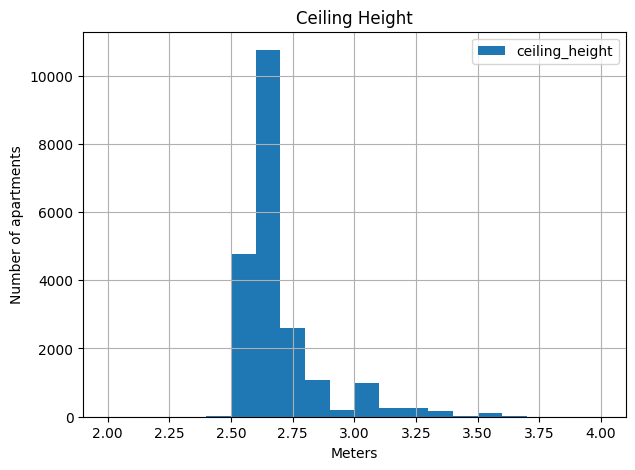

In [102]:
# ceiling_height
data.plot(y = 'ceiling_height', kind = 'hist', bins = 20, grid=True, figsize = (7,5), range = (2,4))
plt.title('Ceiling Height')
plt.xlabel('Meters')
plt.ylabel('Number of apartments')
plt.show()

In [103]:
data['ceiling_height'].describe()

count    21234.000000
mean         2.675130
std          0.165935
min          2.450000
25%          2.600000
50%          2.650000
75%          2.700000
max          3.600000
Name: ceiling_height, dtype: float64

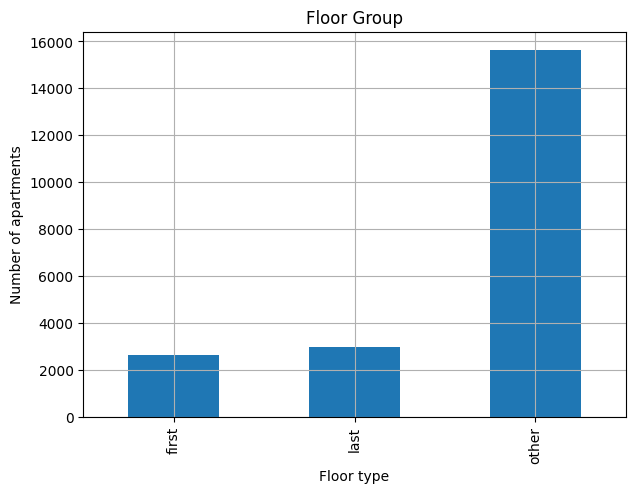

In [104]:
# floor_group
data.groupby('floor_group')['total_area'].count().plot( kind = 'bar', grid=True, figsize = (7,5))
plt.title('Floor Group')
plt.xlabel('Floor type')
plt.ylabel('Number of apartments')
plt.show()

In [105]:
data['floor_group'].describe()

count     21234
unique        3
top       other
freq      15634
Name: floor_group, dtype: object

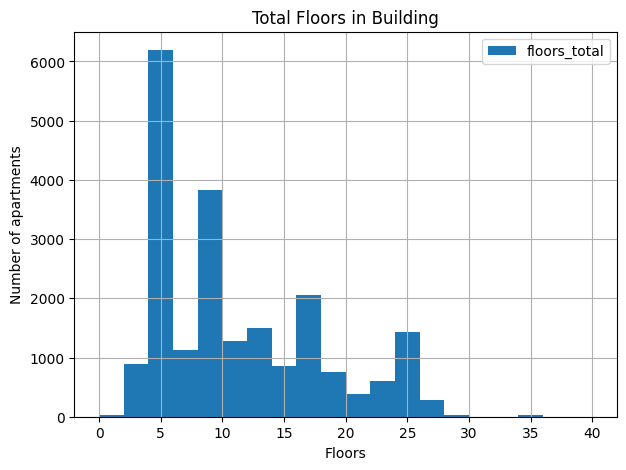

In [106]:
# floors_total
data.plot(y = 'floors_total', kind = 'hist', bins = 20, grid=True, figsize = (7,5), range = (0,40))
plt.title('Total Floors in Building')
plt.xlabel('Floors')
plt.ylabel('Number of apartments')
plt.show()

In [107]:
data['floors_total'].describe()

count    21234.000000
mean        10.839927
std          6.607893
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         52.000000
Name: floors_total, dtype: float64

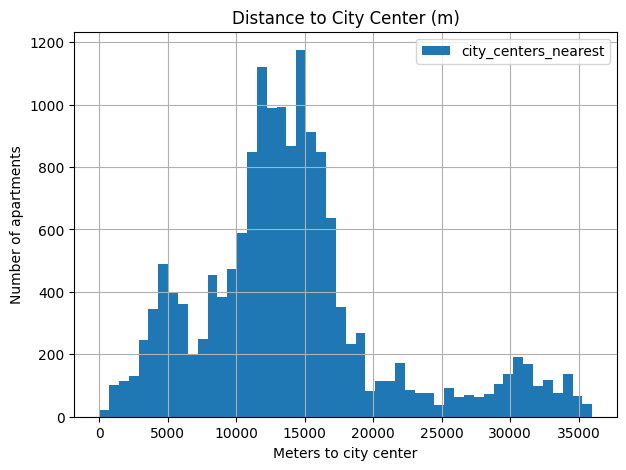

In [108]:
# city_centers_nearest
data.plot(y = 'city_centers_nearest', kind = 'hist', bins = 50, grid=True, figsize = (7,5), range = (0,36000))
plt.title('Distance to City Center (m)')
plt.xlabel('Meters to city center')
plt.ylabel('Number of apartments')
plt.show()

In [109]:
data['city_centers_nearest'].describe()

count    16061.000000
mean     14045.353278
std       7046.073585
min        287.000000
25%      10130.000000
50%      13299.000000
75%      16275.000000
max      35892.000000
Name: city_centers_nearest, dtype: float64

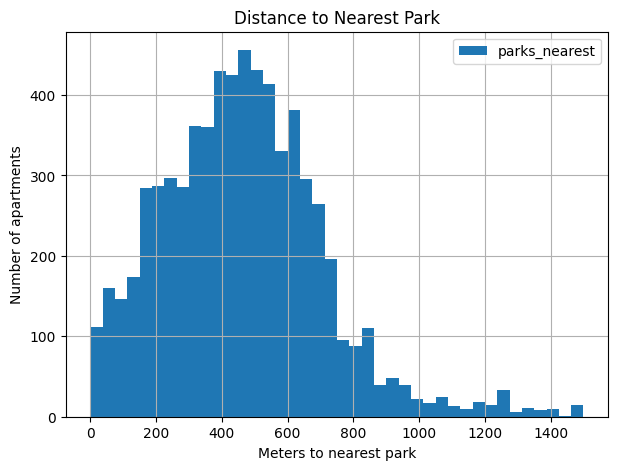

In [110]:
# parks_nearest
data.plot(y = 'parks_nearest', kind = 'hist', bins = 40, grid=True, figsize = (7,5), range = (0,1500))
plt.title('Distance to Nearest Park')
plt.xlabel('Meters to nearest park')
plt.ylabel('Number of apartments')
plt.show()

In [111]:
data['parks_nearest'].describe()

count    6863.000000
mean      497.703045
std       345.010478
min         1.000000
25%       294.000000
50%       458.000000
75%       619.000000
max      3190.000000
Name: parks_nearest, dtype: float64

!!!


***Conclusions on Parameter Analysis***

- **Total Area**: The majority of apartments are under 100 m²; areas larger than this are rare. Although the original dataframe contained several anomalous outliers exceeding 200 m², the upper limit was restricted to 120 m² in the previous data cleaning step.
- **Living Area**: The most common living areas range from 15 to 50 m². Values above 60–65 m² are sporadic. The histogram displays two distinct peaks, likely corresponding to standard living areas for 1-room and 2-room apartments, respectively (followed by a smaller peak for 3-room apartments).
- **Kitchen Area**: Kitchen areas predominantly fall between 5 and 13 m². Areas exceeding 20 m² are rare, and those above 30 m² are isolated cases.
- **Apartment Price**: Prices mostly cluster around 3–5 million. Properties exceeding 15 million are scarce and appear anomalous, with some being significantly more expensive (noting that a portion of the extremely high-priced outliers was previously removed from the dataset).
- **Rooms**: The dataset primarily consists of 1-, 2-, and 3-room apartments, with a small proportion of 4-room properties. Listings with 5 or more rooms appear anomalous (even considering potential apartment combinations) and may represent separate houses.
- **Ceiling Height**: The majority of properties have ceiling heights between 2.5 and 3.1 meters. While values exceeding 3.5 meters appear anomalous, they may correspond to historic luxury buildings in Saint Petersburg, where ceilings can reach up to 5 meters.
- **Floor Group**: The "other" floor category is the most frequent, followed by "last" and "first." This is expected, as the majority of apartments are situated between the ground and top floors.
- **Total Floors in Building**: Five-story buildings represent the largest segment in the dataset. Distinct peaks are also observed at 9, 17, and 25 floors. This aligns with the architectural reality of Saint Petersburg, where five-story buildings are predominant.
- **Distance to City Center**: The highest volume of sales listings comes from residential areas on the outskirts (12,000–15,000 m), with a significant secondary peak observed at a distance of 5,000 meters from the city center.
- **Distance to Nearest Park**: The number of listings decreases as the distance to the nearest park increases. The average distance to a park is approximately 200–700 meters.

**Summary**: The typical listing describes a 1- or 2-room apartment in a 5-story building, with an area of 40 m², a 7 m² kitchen, 2.5-meter ceilings, located approximately 13 km from the city center.

### 4.2 Analysis of Sale Duration

In [112]:
data['days_exposition'].describe()

count    18525.000000
mean       176.346451
std        214.304689
min          1.000000
25%         45.000000
50%         93.000000
75%        224.000000
max       1580.000000
Name: days_exposition, dtype: float64

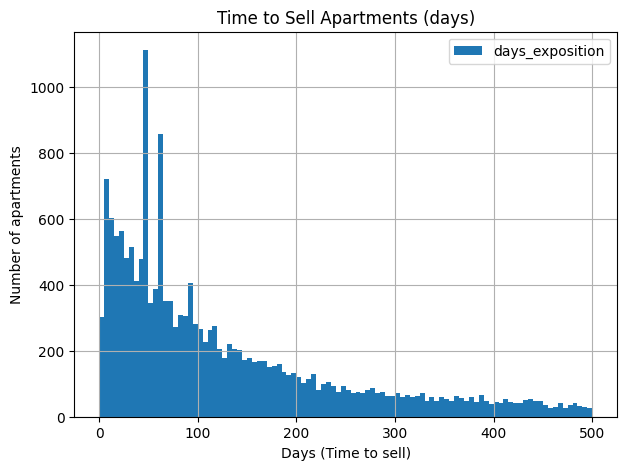

In [113]:
# plotting the histogram
data.plot(y = 'days_exposition', kind = 'hist', bins = 100, grid=True, figsize = (7,5), range = (0, 500))
plt.title('Time to Sell Apartments (days)')
plt.xlabel('Days (Time to sell)')
plt.ylabel('Number of apartments')
plt.show()

In [114]:
# calculating the mean and median
print('Time to sell (mean):', round(data['days_exposition'].mean(), 3))
print('Time to sell (median):', data['days_exposition'].median())

Time to sell (mean): 176.346
Time to sell (median): 93.0


**Conclusion:** The median time to sell an apartment is 93 days (approximately 3 months), while the average (mean) time is 176 days (approximately 6 months). Typically, a standard property sale takes 2–3 months, depending on associated factors (area, price, and distance from the city center).

- **Fast Sales:** Sales completed within 45 days (the first quartile) can be considered "fast." The significant peak observed in this range suggests that listings might be automatically removed or unpublished after this period, creating the appearance of a rapid sale in the dataset.

- **Unusually Long Sales:** Transactions taking 224 days or more (beyond the third quartile) are considered unusually long. These cases may represent properties that remained unsold for extended periods; for example, the maximum duration recorded in the dataset is 1,580 days (~4.3 years).

### 4.3 Analysis of factors influencing the total apartment price

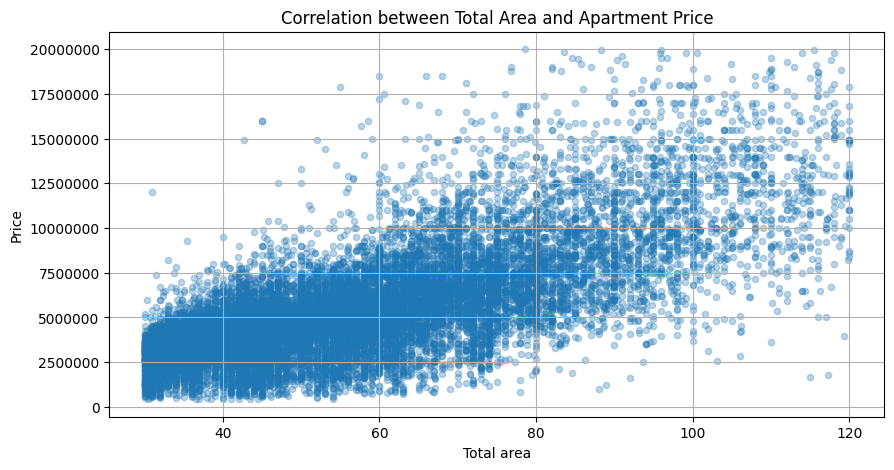

In [115]:
# total area vs. last price
data.plot(x = 'total_area', y = 'last_price', kind = 'scatter', grid=True, figsize=(10,5), alpha=0.3)
plt.title('Correlation between Total Area and Apartment Price')
plt.ticklabel_format(style='plain')
plt.xlabel('Total area')
plt.ylabel('Price')
plt.show()

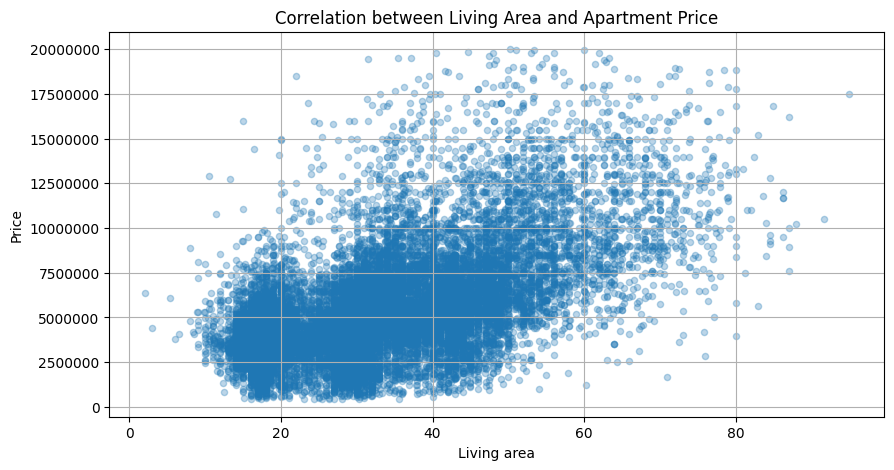

In [116]:
# living area vs. last price
data.plot(x = 'living_area', y = 'last_price', kind = 'scatter', grid=True, figsize=(10,5), alpha=0.3)
plt.title('Correlation between Living Area and Apartment Price')
plt.ticklabel_format(style='plain')
plt.xlabel('Living area')
plt.ylabel('Price')
plt.show()

In [117]:
data['kitchen_area'].describe()

count    21234.000000
mean         9.386591
std          4.179925
min          2.000000
25%          6.500000
50%          8.700000
75%         11.000000
max         64.000000
Name: kitchen_area, dtype: float64

<Axes: >

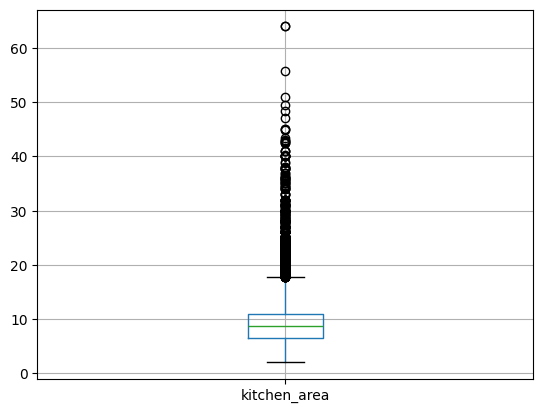

In [118]:
data.boxplot(column='kitchen_area')

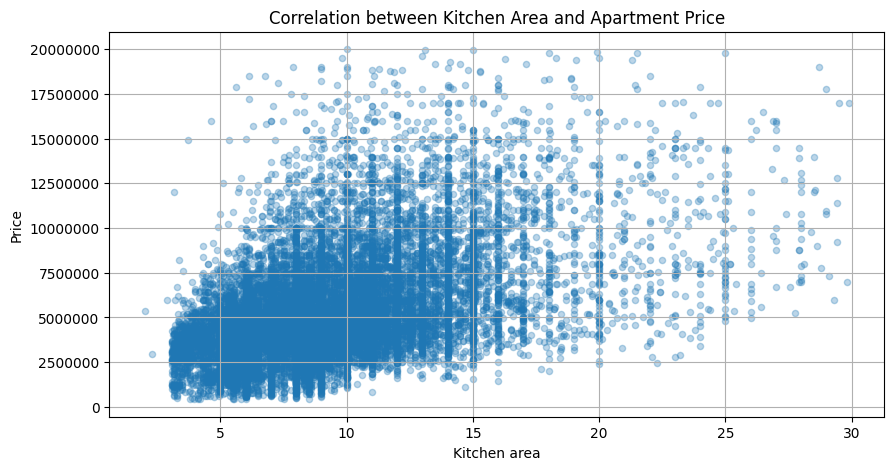

In [119]:
# kitchen area vs. last price
data.loc[data['kitchen_area'] < 30].plot(x = 'kitchen_area', y = 'last_price', kind = 'scatter', 
                                         grid=True, figsize=(10, 5), alpha=0.3)
plt.title('Correlation between Kitchen Area and Apartment Price')
plt.ticklabel_format(style='plain')
plt.xlabel('Kitchen area')
plt.ylabel('Price')
plt.show()

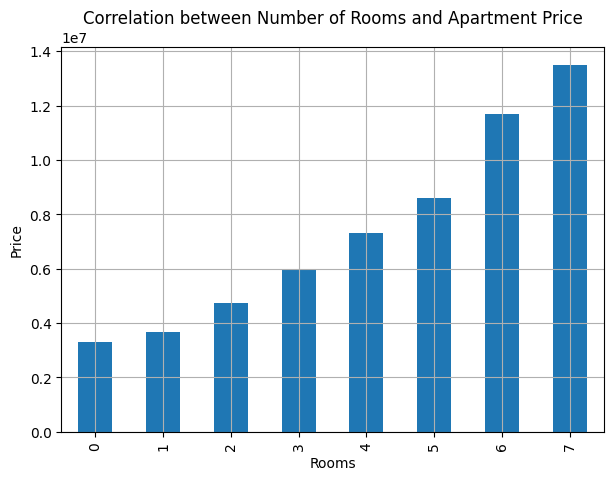

In [120]:
# rooms vs. last price
data.groupby('rooms')['last_price'].median().plot(kind = 'bar', grid=True, figsize = (7,5))
plt.title('Correlation between Number of Rooms and Apartment Price')
plt.xlabel('Rooms')
plt.ylabel('Price')
plt.show()

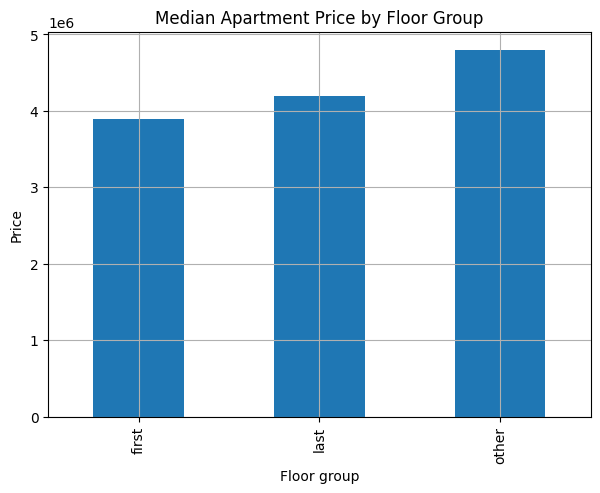

In [121]:
# floor group vs. price
data.groupby('floor_group')['last_price'].median().plot(kind = 'bar', grid=True, figsize = (7,5))
plt.title('Median Apartment Price by Floor Group')
plt.xlabel('Floor group')
plt.ylabel('Price')
plt.show()

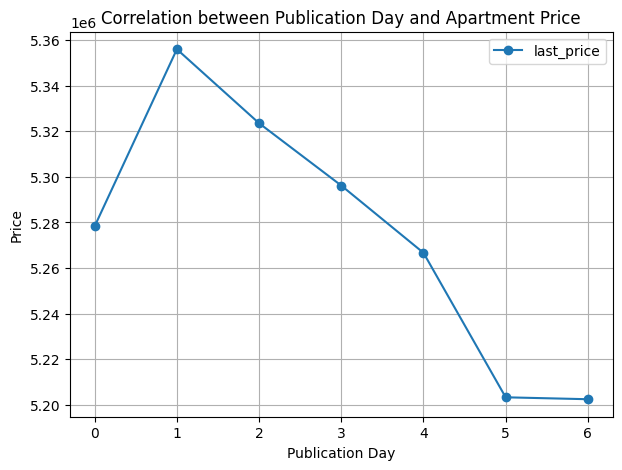

In [122]:
# weekday exposition vs. price
(
    data.pivot_table(index='weekday_exposition', values='last_price')
    .plot(grid=True, figsize=(7,5), style = '-o')
)
plt.title('Correlation between Publication Day and Apartment Price')
plt.xlabel('Publication Day')
plt.ylabel('Price')
plt.show()

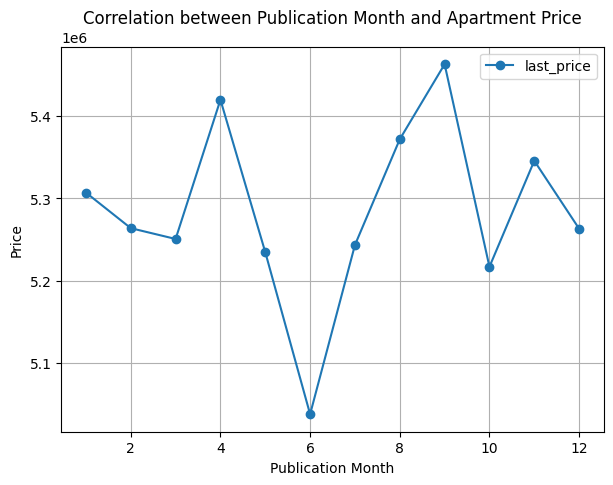

In [123]:
# month exposition vs. price
(
    data.pivot_table(index='month_exposition', values='last_price')
    .plot(grid=True, figsize=(7,5), style = '-o')
)
plt.title('Correlation between Publication Month and Apartment Price')
plt.xlabel('Publication Month')
plt.ylabel('Price')
plt.show()

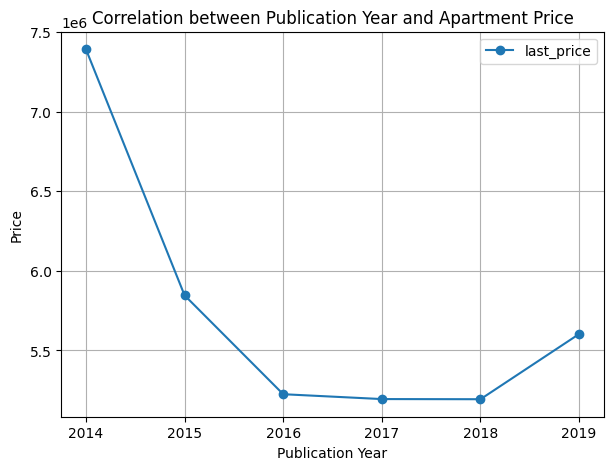

In [124]:
# year exposition vs. price
(
    data.pivot_table(index='year_exposition', values='last_price')
    .plot(grid=True, figsize=(7,5), style = '-o')
)
plt.title('Correlation between Publication Year and Apartment Price')
plt.xlabel('Publication Year')
plt.ylabel('Price')
plt.show()

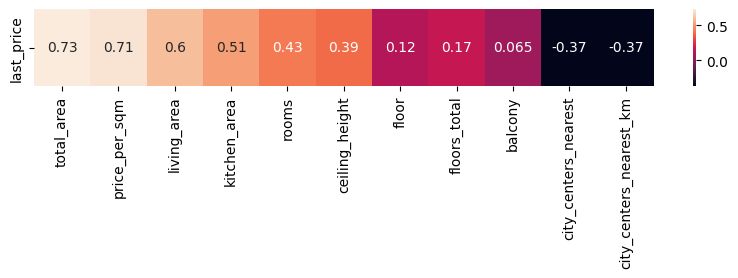

In [125]:
fig = plt.figure(figsize=(10, 1))
sns.heatmap(data[['last_price',
                    'total_area',
                      'price_per_sqm',
                      'living_area',
                      'kitchen_area',
                      'rooms',
                      'ceiling_height',
                      'floor',
                      'floors_total',
                      'balcony', 
                      'city_centers_nearest',
                      'city_centers_nearest_km'
                 ]].corr().loc[['last_price']].drop(columns='last_price'), annot=True);

**Conclusions on the Analysis of Factors Influencing Total Apartment Price**

- **Total Area**: A strong positive correlation exists between total area and price; as the area increases, the price rises. The correlation coefficient is high (0.73).
- **Living Area**: The living area also influences the apartment price, showing a moderate correlation of 0.60.
- Kitchen Area: The correlation between kitchen area and price (0.51) is lower than that of the total and living areas. A potential reason is that kitchen size may be a less critical factor for buyers compared to overall and living space.
- **Number of Rooms**: While the number of rooms positively influences price, the correlation (0.43) is weaker than that of the area variables. This suggests the existence of apartments with fewer but larger rooms, or that centrally located apartments may have fewer rooms yet command higher prices due to location.
- **Floor Type**: On average, prices for ground-floor apartments are 20% lower than those on other floors (excluding the top floor). Apartments on the top floor are slightly more expensive than those on the ground floor, while properties located between the ground and top floors command the highest prices.
- **Publication Date Analysis**:

    - *Day of the Week:* Listings published on Tuesdays command the highest prices, while those published on Saturdays and Sundays are the cheapest.
    - *Month:* The highest prices are observed in April and September, while June exhibits the lowest prices.
    - *Year:* Prices peaked in 2014 (likely influenced by the economic aftermath of the 2008–2013 period), followed by a significant decline between 2016 and 2018. In 2019, prices began to rise again as the economy stabilized.

### 4.4 Analysis of the Top 10 Localities by Number of Listings and Price per Square Meter

In [126]:
# create a pivot table showing the number of listings and average price per square meter for these localities
top10_locality_names = data.pivot_table(index = 'locality_clean_name', values = 'price_per_sqm',
                                       aggfunc=['count', 'mean'])
top10_locality_names.columns = ['count', 'mean']
top10_locality_names = top10_locality_names.sort_values('count', ascending = False).head(10)
top10_locality_names

,count,mean
locality_clean_name,,
Санкт-Петербург,14061,108326.786938
Мурино,511,84652.891859
Кудрово,427,94597.578618
Шушары,422,77688.990261
Всеволожск,381,67100.059711
Пушкин,338,101802.405266
Колпино,326,75143.728681
Парголово,320,90239.779187
Гатчина,300,69019.028100


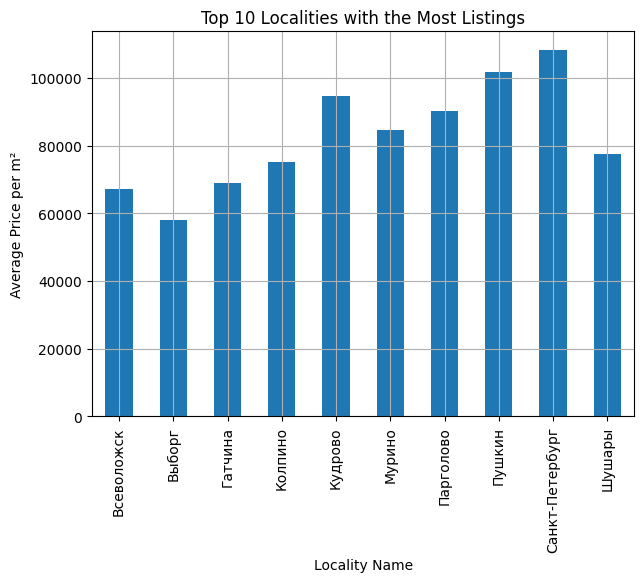

In [127]:
top10_locality_names.groupby('locality_clean_name')['mean'].mean().plot(kind = 'bar', grid=True, figsize = (7,5))
plt.title('Top 10 Localities with the Most Listings')
plt.xlabel('Locality Name')
plt.ylabel('Average Price per m²')
plt.show()

In [128]:
# highlighting localities with the highest and lowest price per square meter
# highest price
top10_locality_names[top10_locality_names['mean']==top10_locality_names['mean'].max()]

,count,mean
locality_clean_name,,
Санкт-Петербург,14061,108326.786938


In [129]:
# lowest price
top10_locality_names[top10_locality_names['mean']==top10_locality_names['mean'].min()]

,count,mean
locality_clean_name,,
Выборг,215,58027.369442


**Conclusion:** As expected, the highest average price per square meter is found in Saint Petersburg. This is followed by Pushkin, which features numerous parks and modern developments. Among the top 10, the lowest prices are observed in Gatchina and Vsevolozhsk (likely due to the commute distance to Saint Petersburg), as well as Vyborg (10th on the list), which is situated at a significant distance from the city.

### 4.5 Analysis of Price per Square Meter in Saint Petersburg per Kilometer of Distance from the Center

In [130]:
# average prices calculated for every kilometer of distance (1 km, 2 km, etc.) from the center
last_price_per_km = (data.query('locality_clean_name == "Санкт-Петербург"')
                    .pivot_table(index='city_centers_nearest_km', values='last_price', aggfunc='mean'))
last_price_per_km

,last_price
city_centers_nearest_km,
0.0,8.898750e+06
1.0,9.991587e+06
2.0,8.979957e+06
3.0,8.223458e+06
4.0,8.703922e+06
5.0,8.853671e+06
6.0,8.228770e+06
7.0,7.794807e+06
8.0,7.646879e+06


In [131]:
m2_price_per_km = (data.query('locality_clean_name == "Санкт-Петербург"')
                    .pivot_table(index='city_centers_nearest_km', values='price_per_sqm', aggfunc='mean'))
m2_price_per_km

,price_per_sqm
city_centers_nearest_km,
0.0,110557.905000
1.0,128407.390159
2.0,124831.370484
3.0,114915.729609
4.0,123589.036515
5.0,127828.807267
6.0,128380.969503
7.0,124085.451594
8.0,120541.113372


In [132]:
data[data['locality_clean_name'] == 'Санкт-Петербург']['city_centers_nearest_km'].describe()

count    14018.000000
mean        12.051505
std          4.641387
min          0.000000
25%          9.000000
50%         13.000000
75%         15.000000
max         29.000000
Name: city_centers_nearest_km, dtype: float64

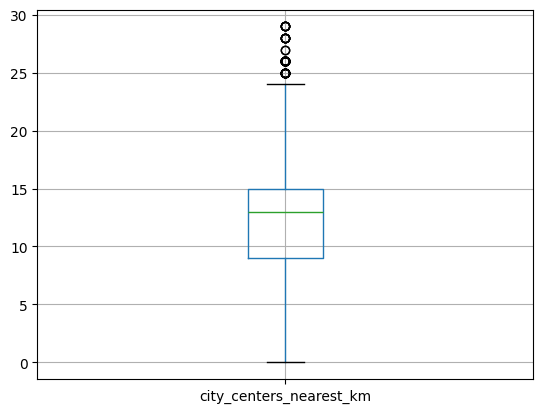

In [133]:
data.query('locality_clean_name == "Санкт-Петербург"').boxplot(column='city_centers_nearest_km');

In [134]:
data.query('locality_clean_name == "Санкт-Петербург" and city_centers_nearest_km == 27')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,kitchen_ratio,living_ratio,locality_type,locality_clean_name,price_per_sqm,weekday_exposition,month_exposition,year_exposition,floor_group,city_centers_nearest_km
651,13,14350000.0,74.0,2017-11-28,2,3.13,5,30.0,3,False,False,False,25.0,0,Санкт-Петербург,23888.0,27313.0,1,1496.0,0,NaN,128.0,0.337838,0.405405,,Санкт-Петербург,193918.92,1,11,2017,other,27.0
5344,6,2250000.0,32.0,2018-02-27,1,2.65,2,16.5,2,False,False,False,7.0,0,Санкт-Петербург,24006.0,27431.0,0,NaN,0,NaN,178.0,0.218750,0.515625,,Санкт-Петербург,70312.50,1,2,2018,last,27.0


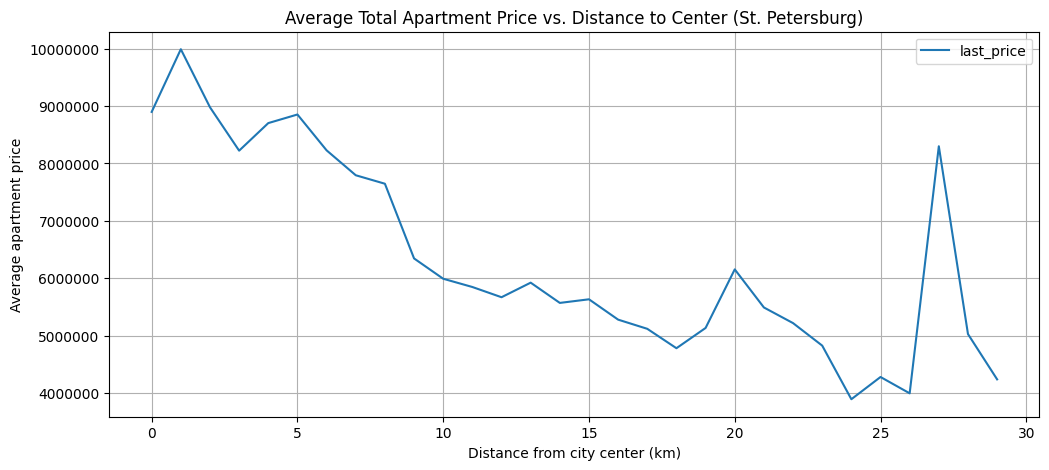

In [135]:
# plotting the change in average price for each kilometer from the center of St. Petersburg
(
    data.query('locality_clean_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_km', values='last_price', aggfunc='mean')
    .plot(grid=True, figsize=(12,5))
)
plt.title('Average Total Apartment Price vs. Distance to Center (St. Petersburg)')
plt.ticklabel_format(style='plain')
plt.xlabel('Distance from city center (km)')
plt.ylabel('Average apartment price')
plt.show()

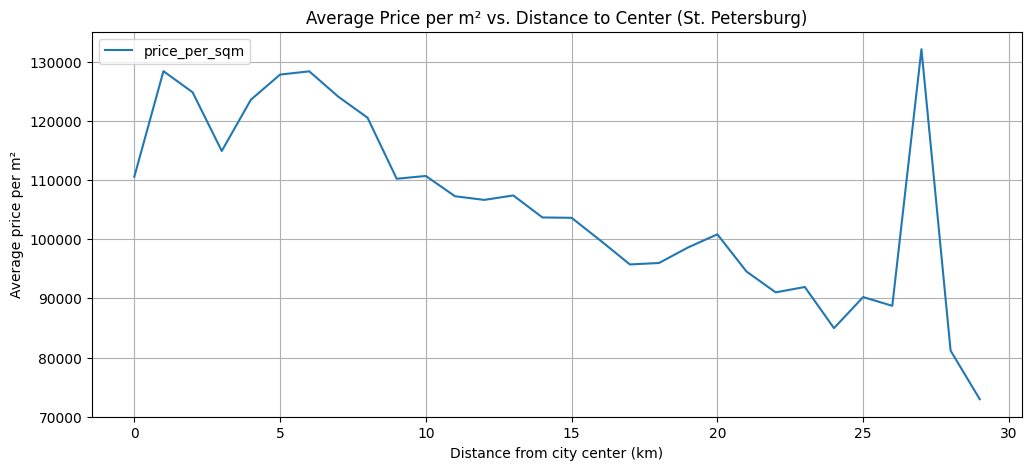

In [136]:
(
    data.query('locality_clean_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_km', values='price_per_sqm', aggfunc='mean')
    .plot(grid=True, figsize=(12,5))
)
plt.title('Average Price per m² vs. Distance to Center (St. Petersburg)')
plt.ticklabel_format(style='plain')
plt.xlabel('Distance from city center (km)')
plt.ylabel('Average price per m²')
plt.show()

**Conclusion:** The most distant property is located 29 km from the center of Saint Petersburg.

Particular attention was drawn to the 27 km mark, where housing prices appeared nearly double those at 26 km and 28 km (suggesting either luxury real estate or insufficient data). An examination of the data rows for the 27 km distance revealed that the observed peak is due to a small sample size (only 2 properties), which resulted in an inflated average price.

Based on the first pivot table and graph, apartment prices are highest within the first 10 km from the center and gradually decrease thereafter. The second pivot table (km/price per m²) and graph indicate noticeable peaks in the average price per square meter at 1–7 km from the city center, followed by a gradual decline.

## 5. Conclusion

Real estate listings for apartments in Saint Petersburg and its surrounding areas were analyzed in this study. During the data preparation phase, data preprocessing was performed (identifying missing values, correcting data types, and eliminating implicit duplicates and anomalies), and new columns containing necessary parameters were engineered to facilitate exploratory analysis.

The exploratory data analysis yielded the following conclusions:

- **Time to Sell (Days on Market)**

The median sale time is 93 days. Sales completed in under 45 days are considered fast (likely due to automatic delisting), while those taking longer than 224 days are considered slow. A significant number of apartments were sold within just a few days of publication, whereas some listings remained on the market for several dozen months (reaching up to ~4 years).

- **Factors Influencing Price**

The total area has the most significant impact on the total apartment price, followed by the price per square meter, living area, kitchen area, number of rooms, and ceiling height.

- *Floor Level:* Ground-floor apartments are cheaper than those on other floors. Top-floor apartments are more expensive than those on the ground floor but cheaper than those on middle floors.

- *Location:* Proximity to the city center correlates with higher prices.

- *Timing:* Listings published on weekdays are priced higher than those published on weekends. Prices are highest in April and September and lowest in June.

- *Yearly Trend:* Apartments sold in 2014 commanded the highest prices (likely due to post-crisis economic conditions); subsequently, prices declined before beginning to recover in 2019.

- **Price per Square Meter in Top 10 Localities**

The highest price per square meter is found in Saint Petersburg (108,326), while the lowest is in Vyborg (58,027).

- **Factors Influencing Price in Central Saint Petersburg**

The most expensive apartments are located in the city center. Prices decrease as the distance from the center increases up to 7 kilometers; beyond this radius, price shows no significant dependence on distance.